# Fase 0 — Exploración del Dataset IroSvA
Análisis estadístico descriptivo del corpus IroSvA (Ortega-Bueno et al., 2019)
sobre las tres variantes dialectales: mexicana, peninsular y cubana.
Se examina la distribución de clases, la presencia de variables lingüísticas
relevantes para la detección de sarcasmo, la estructura del vocabulario
y las relaciones entre características.

La exploración se realiza exclusivamente sobre el conjunto de entrenamiento
para evitar contaminación con los datos de test.

## 1. Importación de librerías

In [13]:
import pandas as pd
import numpy as np
import re
import emoji
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords', quiet=True)
sns.set_style('whitegrid')

## 2. Carga de las tres variantes dialectales (solo train)

In [14]:
df_mx = pd.read_csv('../data/irosva.mx.training.csv')
df_es = pd.read_csv('../data/irosva.es.training.csv')
df_cu = pd.read_csv('../data/irosva.cu.training.csv')

DATASETS = [
    ('México',  df_mx),
    ('España',  df_es),
    ('Cuba',    df_cu),
]

print(f'Columnas: {df_mx.columns.tolist()}')
print(f'Tipos:    {df_mx.dtypes.to_dict()}')
print(f'\nRegistros por variante:')
for nombre, df in DATASETS:
    print(f'  {nombre}: {len(df):,}')
print(f'  Total:  {sum(len(df) for _, df in DATASETS):,}')

Columnas: ['ID', 'TOPIC', 'IS_IRONIC', 'MESSAGE']
Tipos:    {'ID': <StringDtype(storage='python', na_value=nan)>, 'TOPIC': <StringDtype(storage='python', na_value=nan)>, 'IS_IRONIC': dtype('int64'), 'MESSAGE': <StringDtype(storage='python', na_value=nan)>}

Registros por variante:
  México: 2,400
  España: 2,400
  Cuba: 2,400
  Total:  7,200


## 3. Validación de calidad: nulos y duplicados

In [15]:
print(f'{"Variante":15} {"Nulos":>7} {"Duplicados en MESSAGE":>25}')
print('-' * 50)
for nombre, df in DATASETS:
    nulos = df.isnull().sum().sum()
    dups  = df.duplicated(subset='MESSAGE').sum()
    print(f'{nombre:15} {nulos:>7} {dups:>25}')

Variante          Nulos     Duplicados en MESSAGE
--------------------------------------------------
México                0                         1
España                0                         2
Cuba                  0                         0


## 4. Distribución de clases
El dataset presenta un desbalance 2:1 (no irónico : irónico) consistente
en las tres variantes (Ortega-Bueno et al., 2019).

In [16]:
print(f'{"Variante":15} {"Total":>7} {"Irónico":>12} {"No irónico":>14}')
print('-' * 52)
for nombre, df in DATASETS:
    total      = len(df)
    ironico    = df['IS_IRONIC'].sum()
    no_ironico = total - ironico
    print(f'{nombre:15} {total:>7,} '
          f'{ironico:>5} ({ironico/total*100:.1f}%) '
          f'{no_ironico:>5} ({no_ironico/total*100:.1f}%)')

Variante          Total      Irónico     No irónico
----------------------------------------------------
México            2,400   800 (33.3%)  1600 (66.7%)
España            2,400   800 (33.3%)  1600 (66.7%)
Cuba              2,400   800 (33.3%)  1600 (66.7%)


## 5. Distribución de longitud de textos por clase y variante
Se analiza la longitud en tokens para identificar diferencias entre
clases que podrían afectar la representación TF-IDF.

In [17]:
def tokenizar_simple(texto):
    """Tokenización básica: minúsculas, solo palabras alfanuméricas."""
    return re.findall(r'\b\w+\b', str(texto).lower())

print(f'{"Variante":15} {"Clase":>12} {"Min":>5} {"Media":>7} '
      f'{"Mediana":>8} {"Max":>6} {"P90":>7}')
print('-' * 65)

for nombre, df in DATASETS:
    for clase, etiqueta in [(1, 'Irónico'), (0, 'No irónico')]:
        lon = df[df['IS_IRONIC'] == clase]['MESSAGE'].apply(
            lambda x: len(tokenizar_simple(x))
        )
        print(f'{nombre:15} {etiqueta:>12} {lon.min():>5} {lon.mean():>7.1f} '
              f'{lon.median():>8.1f} {lon.max():>6} {lon.quantile(0.9):>7.1f}')
    print()

Variante               Clase   Min   Media  Mediana    Max     P90
-----------------------------------------------------------------
México               Irónico     3    16.9     14.0     56    31.0
México            No irónico     2    21.4     18.0     61    44.0

España               Irónico     2    22.5     20.0     54    42.0
España            No irónico     2    26.4     24.0     62    46.0

Cuba                 Irónico     1    27.1     26.0     66    48.0
Cuba              No irónico     1    28.5     28.0     61    48.0



## 6. Ejemplos de tweets irónicos y no irónicos

In [18]:
for nombre, df in DATASETS:
    print(f'\n=== {nombre.upper()} — TWEETS IRÓNICOS ===')
    for tweet in df[df['IS_IRONIC'] == 1]['MESSAGE'].head(3).values:
        print(' -', tweet)
    print(f'\n=== {nombre.upper()} — TWEETS NO IRÓNICOS ===')
    for tweet in df[df['IS_IRONIC'] == 0]['MESSAGE'].head(3).values:
        print(' -', tweet)


=== MÉXICO — TWEETS IRÓNICOS ===
 - Rica económicamente, pero muy pobre en objetividad.
 - En algo tiene razón, mafias hay en todo, hasta en su 4t.
 - ¿De cuándo acá tan preocupados por la ciencia y la investigación?

=== MÉXICO — TWEETS NO IRÓNICOS ===
 - Lo más grave es que en la entrevista menciona que, el modelo científico que debemos seguir es el de Cuba. ¿De dónde salió ésta gente? Su visión del mundo es completamente anacrónica y desinformada.
 - Y tanta gente capacitada que se fue a  la banca por causa de estos ineptos
 - De nada; si se van a gastar mis impuestos que mejor que sea en algo que nos mejore como país.

=== ESPAÑA — TWEETS IRÓNICOS ===
 - @ArmandoRuido007 @ANTI_MERMA50 @JoanTarda En vez de Joan Tarda van a llamarle “No han tarda” en callarle la boca 🤣🤣
 - @El_Plural Joan Tardà responderá a Vox en catalán....si, si, https://t.co/EpShFy8OfV
 - @orioldebalanzo Que hayan dejado marcharse libre a Joan Tardà eleva la media de la Justicia española. Ya casi somos Turquía.


## 7. Extracción y análisis de variables lingüísticas por clase

Se analizan 9 variables lingüísticas asociadas a la detección de sarcasmo.
Todas se extraen del texto original antes del preprocesamiento para capturar
emojis, elongación y signos de puntuación en su forma natural.

In [19]:
# ── Normalización de tildes ──────────────────────────────────────────────────
def quitar_tildes(texto):
    """Convierte caracteres acentuados a su forma base para capturar
    variantes de escritura informal (jamás→jamas, ningún→ningun)."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

# ── Lista de negaciones en español ───────────────────────────────────────────
# Fuente: Real Academia Española y Asociación de Academias de la Lengua
# Española (2011). Nueva gramática básica de la lengua española.
# Clasificación oficial:
#   Adverbios:               no, nunca, jamás, tampoco, nada (uso adverbial)
#   Pronombres/determinantes: nadie, ninguno/a/os/as, ningún, nada
#   Conjunciones:            ni, sino
#   Preposición:             sin
NEGACIONES = {
    'no', 'nunca', 'jamas', 'tampoco',
    'nada', 'nadie',
    'ningun', 'ninguno', 'ninguna', 'ningunos', 'ningunas',
    'ni', 'sino',
    'sin'
}

FEATURES = ['n_exc', 'n_int', 'n_may', 'n_emo', 'n_ris',
            'n_neg', 'n_elo', 'n_com', 'n_pun']
NOMBRES  = [
    'Exclamaciones', 'Interrogaciones', 'Mayúsculas enfáticas',
    'Emojis', 'Risas', 'Negaciones',
    'Elongación', 'Comillas', 'Puntos suspensivos'
]

In [20]:
def extraer_features(texto):
    """
    Extrae 9 variables lingüísticas como conteos sobre el texto original.
    """
    texto_str  = str(texto)
    texto_norm = quitar_tildes(texto_str.lower())
    palabras   = re.findall(r'\b\w+\b', texto_norm)

    # 1. Exclamaciones: signos ! y ¡
    # (González-Ibáñez et al., 2011; Joshi et al., 2015)
    n_exc = texto_str.count('!') + texto_str.count('¡')

    # 2. Interrogaciones: signos ? y ¿
    # (González-Ibáñez et al., 2011; Joshi et al., 2015)
    n_int = texto_str.count('?') + texto_str.count('¿')

    # 3. Mayúsculas enfáticas: palabras de 3+ chars en mayúsculas
    # Umbral de 3 chars reduce ruido de siglas de 2 letras
    # (Joshi et al., 2015; Šandor & Bagić Babac, 2023)
    n_may = len(re.findall(r'\b[A-ZÁÉÍÓÚÜÑ]{3,}\b', texto_str))

    # 4. Emojis: conteo antes de conversión a texto
    # (González-Ibáñez et al., 2011; Joshi et al., 2015)
    n_emo = sum(1 for c in texto_str if c in emoji.EMOJI_DATA)

    # 5. Risas: expresiones en español e inglés
    # (González-Ibáñez et al., 2011)
    n_ris = len(re.findall(
        r'\b(ja+ja+|je+je+|ji+ji+|ha+ha+|xs+|xd+|lol+|jsjs)\b',
        texto_norm
    ))

    # 6. Negaciones: clasificación RAE (2011), comparación normalizada
    # (González-Ibáñez et al., 2011; RAE, 2011)
    n_neg = sum(1 for p in palabras if p in NEGACIONES)

    # 7. Elongación: mismo carácter repetido 3+ veces consecutivas
    # (Šandor & Bagić Babac, 2023; Joshi et al., 2016)
    n_elo = len(re.findall(r'(.)\1{2,}', texto_norm))

    # 8. Comillas: distanciamiento irónico (dobles, simples, españolas)
    # (González-Ibáñez et al., 2011; Šandor & Bagić Babac, 2023)
    n_com = len(re.findall(r'["\'\u2018\u2019\u201c\u201d«»]', texto_str))

    # 9. Puntos suspensivos: tono suspensivo ('...', '…')
    # (Šandor & Bagić Babac, 2023; Joshi et al., 2016)
    n_pun = texto_str.count('...') + texto_str.count('\u2026')

    return {
        'n_exc': n_exc, 'n_int': n_int, 'n_may': n_may,
        'n_emo': n_emo, 'n_ris': n_ris, 'n_neg': n_neg,
        'n_elo': n_elo, 'n_com': n_com, 'n_pun': n_pun
    }


  México

  Presencia (% de textos con al menos 1 ocurrencia):
  Variable                  No irónico    Irónico
  ------------------------------------------------
  Exclamaciones                  14.4%      20.6%
  Interrogaciones                18.3%      20.6%
  Mayúsculas enfáticas           14.4%      13.0%
  Emojis                          7.9%      16.6%
  Risas                           0.4%       0.9%
  Negaciones                     43.9%      37.1%
  Elongación                     18.4%      32.2%
  Comillas                        5.9%       9.5%
  Puntos suspensivos             12.1%      18.5%

  Media de ocurrencias por texto:
  Variable                  No irónico    Irónico
  ------------------------------------------------
  Exclamaciones                  0.374      0.585
  Interrogaciones                0.371      0.412
  Mayúsculas enfáticas           0.566      0.359
  Emojis                         0.207      0.534
  Risas                          0.005      0.009

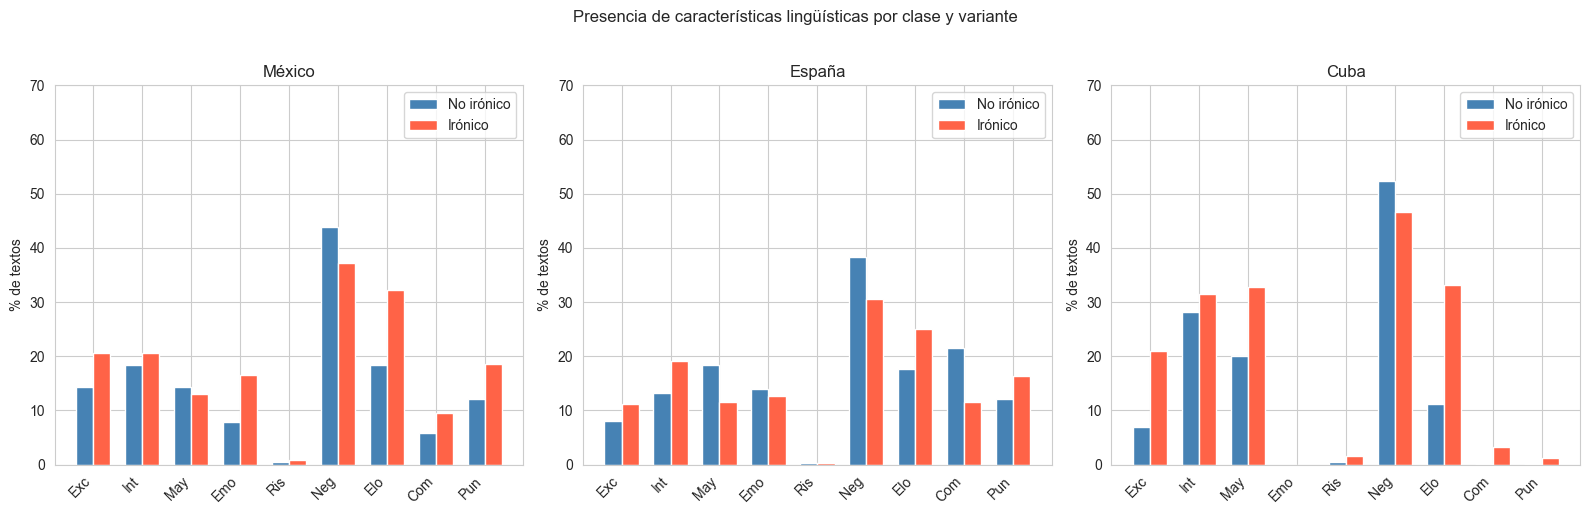

In [28]:
def analizar_features(nombre, df):
    """Extrae features y muestra presencia y media por clase."""
    feats = df['MESSAGE'].apply(extraer_features).apply(pd.Series)
    df_f  = pd.concat([df[['IS_IRONIC']], feats], axis=1)

    print(f'\n{"="*58}')
    print(f'  {nombre}')
    print(f'{"="*58}')

    # Presencia (% textos con al menos 1 ocurrencia)
    print(f'\n  Presencia (% de textos con al menos 1 ocurrencia):')
    print(f'  {"Variable":23} {"No irónico":>12} {"Irónico":>10}')
    print(f'  {"-"*48}')
    for feat, nom in zip(FEATURES, NOMBRES):
        p = df_f.groupby('IS_IRONIC')[feat].apply(lambda x: (x > 0).mean() * 100)
        print(f'  {nom:23} {p[0]:>11.1f}% {p[1]:>9.1f}%')

    # Media de ocurrencias por texto
    print(f'\n  Media de ocurrencias por texto:')
    print(f'  {"Variable":23} {"No irónico":>12} {"Irónico":>10}')
    print(f'  {"-"*48}')
    for feat, nom in zip(FEATURES, NOMBRES):
        m = df_f.groupby('IS_IRONIC')[feat].mean()
        print(f'  {nom:23} {m[0]:>12.3f} {m[1]:>10.3f}')

    return df_f

# Ejecutar para cada variante
resultados = {}
for nombre, df in DATASETS:
    resultados[nombre] = analizar_features(nombre, df)

# Figura: presencia de características por clase y variante
import numpy as np

NOMBRES_CORTOS = ['Exc', 'Int', 'May', 'Emo', 'Ris', 'Neg', 'Elo', 'Com', 'Pun']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (nombre, df_f) in zip(axes, resultados.items()):
    presencia = {}
    for feat, nom in zip(FEATURES, NOMBRES_CORTOS):
        p = df_f.groupby('IS_IRONIC')[feat].apply(lambda x: (x > 0).mean() * 100)
        presencia[nom] = [p[0], p[1]]

    x = np.arange(len(NOMBRES_CORTOS))
    width = 0.35
    ax.bar(x - width/2, [presencia[n][0] for n in NOMBRES_CORTOS],
           width, label='No irónico', color='steelblue')
    ax.bar(x + width/2, [presencia[n][1] for n in NOMBRES_CORTOS],
           width, label='Irónico', color='tomato')
    ax.set_title(nombre)
    ax.set_xticks(x)
    ax.set_xticklabels(NOMBRES_CORTOS, rotation=45, ha='right')
    ax.set_ylabel('% de textos')
    ax.set_ylim(0, 70)
    ax.legend()

plt.suptitle('Presencia de características lingüísticas por clase y variante',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/figura_presencia_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlación entre las 9 características lingüísticas
Se analiza la correlación entre variables para identificar posibles
redundancias o multicolinealidad relevante para LR y SVM.

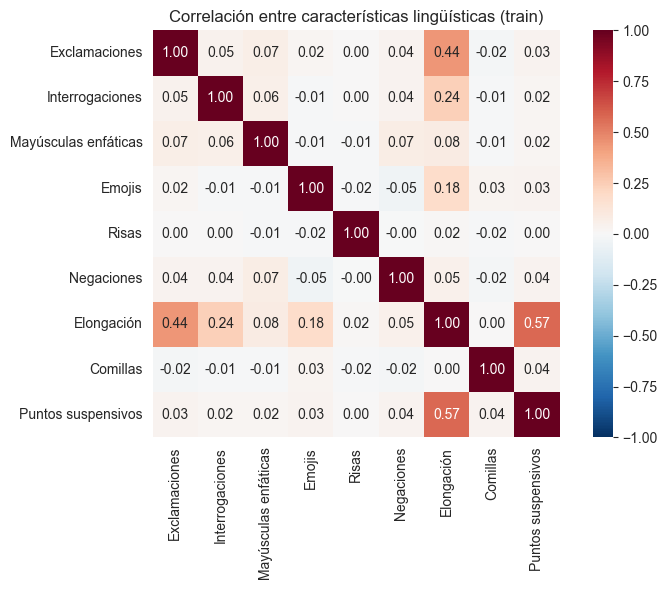


Pares con |correlación| > 0.3:
  Exclamaciones — Elongación: 0.440
  Elongación — Puntos suspensivos: 0.571


In [29]:
# Calcular features sobre todo el train (las 3 variantes juntas)
df_all_train = pd.concat([df for _, df in DATASETS], ignore_index=True)
feats_all = df_all_train['MESSAGE'].apply(extraer_features).apply(pd.Series)

corr = feats_all[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    xticklabels=NOMBRES, yticklabels=NOMBRES,
    square=True, ax=ax
)
ax.set_title('Correlación entre características lingüísticas (train)')
plt.tight_layout()
plt.savefig('../data/correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con correlación > 0.3 (en valor absoluto)
print('\nPares con |correlación| > 0.3:')
found = False
for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3:
            print(f'  {NOMBRES[i]} — {NOMBRES[j]}: {r:.3f}')
            found = True
if not found:
    print('  Ningún par supera |0.3|. No se detecta multicolinealidad relevante.')

## 9. Palabras más frecuentes por clase y variante
Se identifican los términos más frecuentes en cada clase para anticipar
qué capturará la vectorización TF-IDF.

In [30]:
STOP_WORDS = set(stopwords.words('spanish'))

def top_palabras(df, clase, n=15):
    """Retorna las n palabras más frecuentes para una clase."""
    textos = df[df['IS_IRONIC'] == clase]['MESSAGE']
    tokens = [t for msg in textos for t in tokenizar_simple(msg)
              if t not in STOP_WORDS and len(t) > 2]
    return Counter(tokens).most_common(n)

for nombre, df in DATASETS:
    print(f'\n{"="*58}')
    print(f'  {nombre} — TOP 15 PALABRAS')
    print(f'{"="*58}')
    print(f'  {"Irónico":<30} {"No irónico":<30}')
    print(f'  {"-"*58}')
    top_ir  = top_palabras(df, 1)
    top_nir = top_palabras(df, 0)
    for i in range(15):
        w_ir,  c_ir  = top_ir[i]  if i < len(top_ir)  else ('', 0)
        w_nir, c_nir = top_nir[i] if i < len(top_nir) else ('', 0)
        print(f'  {w_ir:<20} {c_ir:>5}     {w_nir:<20} {c_nir:>5}')


  México — TOP 15 PALABRAS
  Irónico                        No irónico                    
  ----------------------------------------------------------
  ser                     36     tierra                 199
  plana                   35     plana                  188
  tierra                  35     gente                   82
  mejor                   29     ser                     82
  pues                    28     gobierno                81
  amlo                    27     solo                    78
  lopezobrador_           26     méxico                  70
  ahora                   26     así                     68
  solo                    26     bien                    65
  tan                     24     pues                    65
  mafia                   24     país                    50
  gente                   24     ahora                   50
  pueblo                  24     presidente              47
  así                     22     ver                     47
  presi

## 10. Análisis de vocabulario
Se analiza el tamaño del vocabulario por variante para contextualizar
el límite de 10,000 términos en TF-IDF (Pandey & Singh, 2023).

In [31]:
print('Tamaño del vocabulario por variante (texto crudo, train):\n')
print(f'{"Variante":15} {"Tokens totales":>16} {"Vocabulario único":>18}')
print('-' * 52)

vocab_total = set()
for nombre, df in DATASETS:
    tokens = [t for msg in df['MESSAGE'] for t in tokenizar_simple(msg)]
    vocab  = set(tokens)
    vocab_total.update(vocab)
    print(f'{nombre:15} {len(tokens):>16,} {len(vocab):>18,}')

print('-' * 52)
all_tokens = [t for _, df in DATASETS for msg in df['MESSAGE'] for t in tokenizar_simple(msg)]
print(f'{"Total":15} {len(all_tokens):>16,} {len(vocab_total):>18,}')
print(f'\nEl límite de 10,000 términos en TF-IDF retiene el '
      f'{min(10000 / len(vocab_total) * 100, 100):.1f}% del vocabulario total.')
print('Este límite se mantuvo tras pruebas empíricas con valores superiores '
      'que no mejoraron el rendimiento.')

Tamaño del vocabulario por variante (texto crudo, train):

Variante          Tokens totales  Vocabulario único
----------------------------------------------------
México                    47,828              8,544
España                    60,156             10,094
Cuba                      67,327              9,714
----------------------------------------------------
Total                    175,311             21,487

El límite de 10,000 términos en TF-IDF retiene el 46.5% del vocabulario total.
Este límite se mantuvo tras pruebas empíricas con valores superiores que no mejoraron el rendimiento.
